In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
import lightgbm as lgb
import shap
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score
from libpysal.weights import Queen
from esda.moran import Moran

C:\Users\x12la\AppData\Local\Temp\ipykernel_19864\2764908229.py:4: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


<h1> Load data 

In [29]:
# I want to see all the stat print outs 
pd.set_option('display.max_rows', None)

In [ ]:
grid = gpd.read_file("LOCUS_IL_Idling.shp").to_crs("EPSG:4326")
warehouses = gpd.read_file("../WarehouseMidwest.shp").to_crs("EPSG:4326")
truck_stops = gpd.read_file("Truck_Stop_Parking.shp").to_crs("EPSG:4326")
terminals = gpd.read_file("../LOCUS/Intermodal_Freight_Facilities_Pipeline_Terminals.shp").to_crs("EPSG:4326")
freight_rail = gpd.read_file("../LOCUS/Intermodal_Freight_Facilities_Rail_TOFC_COFC.shp").to_crs("EPSG:4326")
airports = gpd.read_file("IL_Airports.shp").to_crs("EPSG:4326")
gas_stations = gpd.read_file("Alternative_Fueling_Stations.shp").to_crs("EPSG:4326")
hpms = gpd.read_file("HPMS_2016_aadt.shp").to_crs("EPSG:4326")

grid = grid.reset_index(drop=True)
grid["grid_id"] = grid.index

In [8]:
domain = grid.geometry.unary_union

warehouses = warehouses[warehouses.intersects(domain)].copy()
truck_stops = truck_stops[truck_stops.intersects(domain)].copy()
terminals = terminals[terminals.intersects(domain)].copy()
freight_rail = freight_rail[freight_rail.intersects(domain)].copy()
airports = airports[airports.intersects(domain)].copy()
gas_stations = gas_stations[gas_stations.intersects(domain)].copy()
hpms = hpms[hpms.intersects(domain)].copy()

In [14]:
warehouses.head()

,$Price/Uni,% 1-Bed,% 2-Bed,% 3-Bed,% 4-Bed,% Studios,Affordable,All-Inclus,All-Suites,Amenities,...,Water,Year Built,Year Renov,Zip,Zoning,layer,path,geometry,Warehouse Square Footage,Warehouse Loading Docks
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,"24 Hour Access, Atrium, Conferencing Facility,...",...,Yes,1980.0,NaN,60515-4053,M1,"illinois_gt20k_A Warehouses >20,000ft",file:///C:/Users/x12la/Downloads/illinois_gt20...,POINT (-88.05580 41.79174),74146,4.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,"Floor Drains, Signage",...,City,1981.0,NaN,60563-2985,Industrial,"illinois_gt20k_A Warehouses >20,000ft",file:///C:/Users/x12la/Downloads/illinois_gt20...,POINT (-88.15698 41.77979),78800,1.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,Fenced Lot,...,City,1995.0,NaN,60188-2068,Industrial,"illinois_gt20k_A Warehouses >20,000ft",file:///C:/Users/x12la/Downloads/illinois_gt20...,POINT (-88.11448 41.89980),38616,2.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,"24 Hour Access, Bio-Tech/ Lab Space, Front Loa...",...,City,1980.0,NaN,60139-2100,I PUD; Glendale Heights,"illinois_gt20k_A Warehouses >20,000ft",file:///C:/Users/x12la/Downloads/illinois_gt20...,POINT (-88.08126 41.92987),105000,10.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,Signage,...,City,1975.0,NaN,60515-4013,ORM,"illinois_gt20k_A Warehouses >20,000ft",file:///C:/Users/x12la/Downloads/illinois_gt20...,POINT (-88.04108 41.79511),23000,6.0


In [15]:
truck_stops.head()

,state_numb,nhs_rest_s,highway_ro,mile_post,municipali,county,state,latitude,longitude,number_of_,geometry
382,17,Coalfield NB,I-55NB,64,Waggoner,NA,IL,39.346960,-89.641058,28,POINT (-89.64106 39.34696)
383,17,Coalfield SB,I-55SB,64,Waggoner,NA,IL,39.351846,-89.644360,28,POINT (-89.64436 39.35185)
384,17,Cumberland Road WB,I-70WB,149,Mckeen,NA,IL,39.423049,-87.661736,39,POINT (-87.66174 39.42305)
385,17,Farm Land EB,I-74EB,156,Farmer City,NA,IL,40.273827,-88.675476,42,POINT (-88.67548 40.27383)
386,17,Farm Land WB,I-74WB,156,Farmer City,NA,IL,40.273827,-88.675476,42,POINT (-88.67548 40.27383)


In [16]:
terminals.head()

,TERM_ID,IRS_ID,HIFLD_ID,COMP_NAME,TERM_NAME,ADDRESS,CITY,STATE,STATE_FIPS,COUNTY,...,ETHANOL,WEBSITE,GOOGLE,BING,ZOOMEARTH,VAL_DATE,SOURCE,LATITUDE,LONGITUDE,geometry
298,17019001,T-37-IL-3358,ANLTK17013,MPLX LP,CHAMPAIGN TERMINAL,511 S. STALEY ROAD,CHAMPAIGN,IL,17,CHAMPAIGN,...,NA,https://www.mplx.com/,"https://www.google.com/maps/@40.1109,-88.3153,...","https://www.bing.com/maps/aerial?q=40.1109,-88...","https://zoom.earth/#view=40.1109,-88.3153,17z",2/20/2021,"EIA,HIFLD,IRS",40.1109,-88.3153,POINT (-88.31530 40.11090)
299,17023002,NA,ANLTK17044,MPLX LP,NA,5825 W CUMBERLAND RD,MARTINSVILLE,IL,17,CLARK,...,NA,http://www.marathonpetroleum.com/,"https://www.google.com/maps/@39.3267,-87.9016,...","https://www.bing.com/maps/aerial?q=39.3267,-87...","https://zoom.earth/#view=39.3267,-87.9016,17z",2/20/2021,HIFLD,39.3267,-87.9016,POINT (-87.90160 39.32670)
300,17031003,NA,ANLTK17016,"AMEROPAN TANK TERMINAL CORPORATION OF MAINE, INC.",NA,3301 SOUTH CALIFORNIA AVENUE,CHICAGO,IL,17,COOK,...,NA,http://ameropanoil.com,"https://www.google.com/maps/@41.8352,-87.6911,...","https://www.bing.com/maps/aerial?q=41.8352,-87...","https://zoom.earth/#view=41.8352,-87.6911,17z",2/20/2021,HIFLD,41.8352,-87.6911,POINT (-87.69110 41.83520)
301,17031004,NA,ANLTK17079,AUX SABLE LIQUID PRODUCTS L.P.,MONEE TERMINAL,6251 W. STEGER ROAD,MONEE,IL,17,COOK,...,N,http://www.rtknet.org,"https://www.google.com/maps/@41.4686,-87.7683,...","https://www.bing.com/maps/aerial?q=41.4686,-87...","https://zoom.earth/#view=41.4686,-87.7683,17z",2/20/2021,"HIFLD,COMPANY WEBSITE/ONLINE INFORMATION,RIGHT...",41.4686,-87.7683,POINT (-87.76830 41.46860)
302,17031005,T-36-IL-3315,ANLTK17004,"BUCKEYE TERMINALS, LLC",ARGO TERMINAL,8600 WEST 71ST. STREET,BEDFORD PARK,IL,17,COOK,...,Y,https://www.buckeye.com/,"https://www.google.com/maps/@41.7627,-87.8363,...","https://www.bing.com/maps/aerial?q=41.7627,-87...","https://zoom.earth/#view=41.7627,-87.8363,17z",2/20/2021,"EIA,HIFLD,IRS,COMPANY WEBSITE/ONLINE INFORMATION",41.7627,-87.8363,POINT (-87.83630 41.76270)


In [17]:
freight_rail.head()

,TERMINAL,TERM_ADDRE,CITY,STATE,ZIP_CODE,PORT,RAIL_CO,EQUIPMENT,ACCESS_RD,SPLC,LAT,LON,geometry
76,"Blue Island, IL",2050 Prairie Street,Blue Island,IL,60406,NaN,IAIS,COFC,W 119th St.,381380,41.662167,-87.673448,POINT (-87.67345 41.66217)
83,"Chiacgo, IL - Dolton (Yard Center)",147th Street & Indiana Avenue,Dolton,IL,60419,NaN,UP,TOFC/COFC,NaN,381412,41.623307,-87.613143,POINT (-87.61314 41.62331)
84,"Chiacgo, IL - Northlake (Global II)",301 W. Lake Street,Northlake,IL,60164,NaN,UP,TOFC/COFC,47th Avenue,381238,41.899018,-87.915050,POINT (-87.91505 41.89902)
85,"Chicago, IL - 59th Street",2101 West 59th Street,Chicago,IL,60636,NaN,CSX,COFC,NaN,380639,41.783835,-87.676976,POINT (-87.67698 41.78384)
86,"Chicago, IL - Bedford Park",7000 West 71st Street,Bedford Park,IL,60638,NaN,CSX,TOFC/COFC,NaN,381315,41.764727,-87.793075,POINT (-87.79308 41.76473)


In [18]:
airports.head()

,OBJECTID,EFF_DATE,SITE_NO,SITE_TYPE_,STATE_CODE,ARPT_ID,CITY,COUNTRY_CO,REGION_COD,ADO_CODE,...,TRNS_STRG_,TRNS_STR_1,TRNS_STR_2,OTHER_SERV,WIND_INDCR,ICAO_ID,MIN_OP_NET,USER_FEE_F,CTA,geometry
0,1,2025-05-15,04363.,A,IL,IL01,ABINGDON,US,AGL,CHI,...,NaN,NaN,NaN,NaN,Y,NaN,N,NaN,NaN,POINT (-90.43818 40.79253)
1,2,2025-05-15,04366.,A,IL,C00,ALEDO,US,AGL,CHI,...,NaN,Y,Y,NaN,Y,NaN,N,NaN,NaN,POINT (-90.73708 41.24864)
2,3,2025-05-15,04366.01,H,IL,12IS,ALEDO,US,AGL,CHI,...,NaN,NaN,NaN,NaN,Y,NaN,N,NaN,NaN,POINT (-90.75940 41.20609)
3,4,2025-05-15,04368.8,A,IL,7IS7,ALHAMBRA,US,AGL,CHI,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,POINT (-89.67008 38.91393)
4,5,2025-05-15,04369.,A,IL,0IL2,ALMA,US,AGL,CHI,...,NaN,NaN,NaN,NaN,Y,NaN,N,NaN,NaN,POINT (-88.99777 38.80305)


In [19]:
gas_stations.head()

,access_cod,access_day,access_det,cards_acce,date_last_,expected_d,fuel_type_,groups_wit,id,maximum_ve,...,bd_blends_,groups_w_1,ev_prici_1,ev_chargin,federal_ag,federal__1,federal__2,ev_netwo_2,ev_netwo_3,geometry
248,public,8am-4:30pm M-F,CALL,Cash D M V,2025-09-12,1899-12-30,LPG,Public - Call ahead,14133,HD,...,NaN,Public - Appeler à l'avance,NaN,None,0,NaN,NaN,NaN,NaN,POINT (-88.17626 40.61441)
249,public,7am-4:30pm daily,CREDIT_CARD_AFTER_HOURS,Cash M V,2025-09-12,1899-12-30,LPG,Public - Credit card after hours,14137,NaN,...,NaN,Public - Carte de crédit après les heures d'ou...,NaN,None,0,NaN,NaN,NaN,NaN,POINT (-90.74496 41.20067)
250,public,"7:30am-4:30pm M-F, 8am-12pm Sat",CALL,CREDIT Debit,2025-10-13,1899-12-30,LPG,Public - Call ahead,14148,HD,...,NaN,Public - Appeler à l'avance,NaN,None,0,NaN,NaN,NaN,NaN,POINT (-89.53425 38.61070)
251,public,8am-5pm M-F,CALL,Cash M V,2025-10-13,1899-12-30,LPG,Public - Call ahead,14158,HD,...,NaN,Public - Appeler à l'avance,NaN,None,0,NaN,NaN,NaN,NaN,POINT (-88.97113 38.31590)
252,public,8am-5pm M-F,NaN,Cash Checks M V,2025-10-13,1899-12-30,LPG,Public,14160,HD,...,NaN,Public,NaN,None,0,NaN,NaN,NaN,NaN,POINT (-89.21532 37.73846)


In [20]:
hpms.head()

,OBJECTID,aadt,aadt_combi,aadt_singl,geometry
1169157,1169158.0,0.0,0.0,0.0,"LINESTRING (-87.52525 41.60683, -87.52198 41.6..."
1186156,1186157.0,0.0,0.0,0.0,"LINESTRING (-87.53162 39.46980, -87.53165 39.4..."
1205411,1205412.0,0.0,0.0,0.0,"LINESTRING (-87.52668 41.11969, -87.52668 41.1..."
1217040,1217041.0,0.0,0.0,0.0,"LINESTRING (-87.52591 40.62155, -87.52593 40.6..."
1421534,1421535.0,5697.0,0.0,0.0,"LINESTRING (-87.52524 41.59562, -87.52519 41.5..."


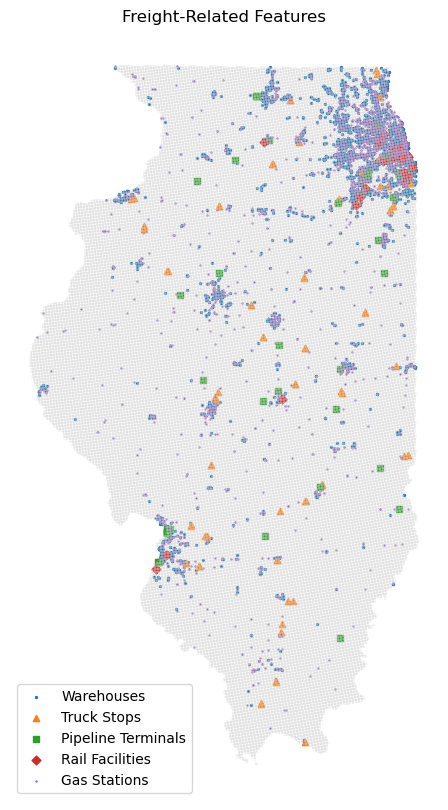

In [27]:
#Quick plot to ensure things are loaded correctly 
fig, ax = plt.subplots(figsize=(10, 10))

grid.boundary.plot(ax=ax, linewidth=0.15, color="lightgray")
warehouses.plot(ax=ax, markersize=2, label="Warehouses")
truck_stops.plot(ax=ax, markersize=20, marker="^", label="Truck Stops")
terminals.plot(ax=ax, markersize=20, marker="s", label="Pipeline Terminals")
freight_rail.plot(ax=ax, markersize=20, marker="D", label="Rail Facilities")
gas_stations.plot(ax=ax, markersize=.5, label="Gas Stations")

ax.legend()
ax.set_title("Freight-Related Features")
ax.set_axis_off()
plt.show()

<h1> Co-located data within model grid 

In [9]:
# Counting how many freight-related features fall within each grid cell.
point_layers = {
    "Warehouse Count": warehouses,
    "Truck Stop Count": truck_stops,
    "Pipeline Terminal Count": terminals,
    "Freight Rail Facility Count": freight_rail,
    "Airport Count": airports,
    "Gas Station Count": gas_stations,}

for column, points in point_layers.items():
    joined = gpd.sjoin(points[["geometry"]], grid[["grid_id", "geometry"]], how="inner", predicate="within")
    counts = joined.groupby("grid_id").size()
    grid[column] = grid["grid_id"].map(counts).fillna(0).astype(int)

In [24]:
# Add warehouse square footage and loading docks to each grid cell. Could additional features later if useful?
warehouses["Warehouse Square Footage"] = pd.to_numeric(warehouses["RBA"], errors="coerce").fillna(0)
warehouses["Warehouse Loading Docks"] = pd.to_numeric(warehouses["Number O_7"], errors="coerce").fillna(0)

warehouse_join = gpd.sjoin(warehouses[["Warehouse Square Footage", "Warehouse Loading Docks", "geometry"]], grid[["grid_id", "geometry"]], how="inner", predicate="within")
warehouse_summary = warehouse_join.groupby("grid_id")[["Warehouse Square Footage", "Warehouse Loading Docks"]].sum()

grid["Warehouse Square Footage"] = grid["grid_id"].map(warehouse_summary["Warehouse Square Footage"]).fillna(0)
grid["Warehouse Loading Dock Count"] = grid["grid_id"].map(warehouse_summary["Warehouse Loading Docks"]).fillna(0)
grid["Average Warehouse Square Footage"] = np.where(grid["Warehouse Count"] > 0, grid["Warehouse Square Footage"] / grid["Warehouse Count"], 0)

# Check that warehouse attributes were carried into the grid correctly.
print(f"Warehouses in domain: {len(warehouses):,}")
print(f"Warehouses assigned to grid: {grid['Warehouse Count'].sum():,.0f}")
print(f"Warehouse square footage in source: {warehouses['Warehouse Square Footage'].sum():,.0f}")
print(f"Warehouse square footage in grid:   {grid['Warehouse Square Footage'].sum():,.0f}")
print(f"Loading docks in source: {warehouses['Warehouse Loading Docks'].sum():,.0f}")
print(f"Loading docks in grid:   {grid['Warehouse Loading Dock Count'].sum():,.0f}")

Warehouses in domain: 7,751
Warehouses assigned to grid: 7,751
Warehouse square footage in source: 630,347,443
Warehouse square footage in grid:   630,347,443
Loading docks in source: 44,077
Loading docks in grid:   44,077


In [11]:
# Intersect roads with the grid and weight AADT by the amount of road in each cell.
# changing the projection here -- EPSG is a geographic CRS which is fine, but i want something
# that can use meters as a metric for distance. So I switched to 26916 per this stackoverflow post 
# https://stackoverflow.com/questions/72569151/what-is-the-units-of-distance-col-and-max-distance-in-geopandas-sjoin-nearest
grid_m = grid.to_crs("EPSG:26916")
hpms_m = hpms.to_crs("EPSG:26916")

roads = gpd.overlay(hpms_m[["aadt", "aadt_combi", "aadt_singl", "geometry"]], grid_m[["grid_id", "geometry"]], how="intersection")
roads["Road Density"] = roads.length / 1000
roads["Total AADT"] = roads["aadt"] * roads["Road Density"]
roads["Combination Truck AADT"] = roads["aadt_combi"] * roads["Road Density"]
roads["Single-Unit Truck AADT"] = roads["aadt_singl"] * roads["Road Density"]
road_summary = roads.groupby("grid_id")[["Road Density", "Total AADT", "Combination Truck AADT", "Single-Unit Truck AADT"]].sum()

grid["Road Density"] = grid["grid_id"].map(road_summary["Road Density"]).fillna(0)
grid["Total AADT"] = grid["grid_id"].map(road_summary["Total AADT"]).fillna(0)
grid["Combination Truck AADT"] = grid["grid_id"].map(road_summary["Combination Truck AADT"]).fillna(0)
grid["Single-Unit Truck AADT"] = grid["grid_id"].map(road_summary["Single-Unit Truck AADT"]).fillna(0)

In [12]:
# Neighborhood = the center grid cell + the eight closest surrounding cells. (i.e. what i define as KNN)
centers = grid.to_crs("EPSG:26916").geometry.centroid
coords = np.column_stack([centers.x, centers.y])

knn = NearestNeighbors(n_neighbors=9)
knn.fit(coords)

_, neighborhood_idx = knn.kneighbors(coords)

neighborhood_features = [
    "Warehouse Count",
    "Warehouse Square Footage",
    "Warehouse Loading Dock Count",
    "Road Density",
    "Single-Unit Truck AADT",
    "Combination Truck AADT",
    "Total AADT",
    "Truck Stop Count",
    "Pipeline Terminal Count",
    "Freight Rail Facility Count",
    "Airport Count",
    "Gas Station Count",]

for column in neighborhood_features:
    values = grid[column].to_numpy()
    grid[f"{column} (Neighborhood)"] = values[neighborhood_idx].sum(axis=1)

# Average warehouse size across all warehouses in the center grid + 8-cell neighborhood.
grid["Average Warehouse Square Footage (Neighborhood)"] = np.where(grid["Warehouse Count (Neighborhood)"] > 0, grid["Warehouse Square Footage (Neighborhood)"] / grid["Warehouse Count (Neighborhood)"], 0)

<h1> Spearman Rank Corr

In [ ]:
targets = ["MDT_avg_da", "HDT_avg_da", "Total_avg_"]

feature_cols = ["Warehouse Count", "Warehouse Square Footage", "Warehouse Loading Dock Count", "Truck Stop Count", "Pipeline Terminal Count", "Freight Rail Facility Count", "Airport Count", "Gas Station Count", "Road Density", "Total AADT", "Combination Truck AADT", "Single-Unit Truck AADT", "Warehouse Count (Neighborhood)", "Warehouse Square Footage (Neighborhood)", "Warehouse Loading Dock Count (Neighborhood)", "Truck Stop Count (Neighborhood)", "Pipeline Terminal Count (Neighborhood)", "Freight Rail Facility Count (Neighborhood)", "Airport Count (Neighborhood)", "Gas Station Count (Neighborhood)", "Road Density (Neighborhood)", "Total AADT (Neighborhood)", "Combination Truck AADT (Neighborhood)", "Single-Unit Truck AADT (Neighborhood)"]

df = grid[feature_cols + targets].replace([np.inf, -np.inf], np.nan).fillna(0).copy()

In [33]:
# Following deSouza et al. (2022), first look at monotonic relationships between idling and each freight-related characteristic.
spearman_results = []

for ycol in targets:
    for xcol in feature_cols:
        rho, p = st.spearmanr(df[xcol], df[ycol], nan_policy="omit")
        spearman_results.append([ycol, xcol, rho, p])

spearman_df = pd.DataFrame(spearman_results, columns=["target", "feature", "spearman_rho", "p_value"])
spearman_df


MDT_avg_da


,target,feature,spearman_rho,p_value
19,MDT_avg_da,Gas Station Count (Neighborhood),0.466591,0.000000e+00
12,MDT_avg_da,Warehouse Count (Neighborhood),0.461331,0.000000e+00
13,MDT_avg_da,Warehouse Square Footage (Neighborhood),0.460148,0.000000e+00
20,MDT_avg_da,Road Density (Neighborhood),0.428844,0.000000e+00
14,MDT_avg_da,Warehouse Loading Dock Count (Neighborhood),0.423337,0.000000e+00
8,MDT_avg_da,Road Density,0.379366,0.000000e+00
11,MDT_avg_da,Single-Unit Truck AADT,0.368986,0.000000e+00
10,MDT_avg_da,Combination Truck AADT,0.368426,0.000000e+00
21,MDT_avg_da,Total AADT (Neighborhood),0.368394,0.000000e+00
23,MDT_avg_da,Single-Unit Truck AADT (Neighborhood),0.368082,0.000000e+00



HDT_avg_da


,target,feature,spearman_rho,p_value
36,HDT_avg_da,Warehouse Count (Neighborhood),0.587179,0.000000e+00
37,HDT_avg_da,Warehouse Square Footage (Neighborhood),0.585677,0.000000e+00
38,HDT_avg_da,Warehouse Loading Dock Count (Neighborhood),0.581900,0.000000e+00
43,HDT_avg_da,Gas Station Count (Neighborhood),0.547323,0.000000e+00
24,HDT_avg_da,Warehouse Count,0.515381,0.000000e+00
25,HDT_avg_da,Warehouse Square Footage,0.515298,0.000000e+00
26,HDT_avg_da,Warehouse Loading Dock Count,0.458662,0.000000e+00
31,HDT_avg_da,Gas Station Count,0.425138,0.000000e+00
44,HDT_avg_da,Road Density (Neighborhood),0.359113,0.000000e+00
34,HDT_avg_da,Combination Truck AADT,0.354438,0.000000e+00



Total_avg_


,target,feature,spearman_rho,p_value
67,Total_avg_,Gas Station Count (Neighborhood),0.465680,0.000000e+00
60,Total_avg_,Warehouse Count (Neighborhood),0.462596,0.000000e+00
61,Total_avg_,Warehouse Square Footage (Neighborhood),0.461517,0.000000e+00
68,Total_avg_,Road Density (Neighborhood),0.428750,0.000000e+00
62,Total_avg_,Warehouse Loading Dock Count (Neighborhood),0.424745,0.000000e+00
56,Total_avg_,Road Density,0.378716,0.000000e+00
59,Total_avg_,Single-Unit Truck AADT,0.368370,0.000000e+00
69,Total_avg_,Total AADT (Neighborhood),0.368118,0.000000e+00
71,Total_avg_,Single-Unit Truck AADT (Neighborhood),0.368032,0.000000e+00
58,Total_avg_,Combination Truck AADT,0.367672,0.000000e+00


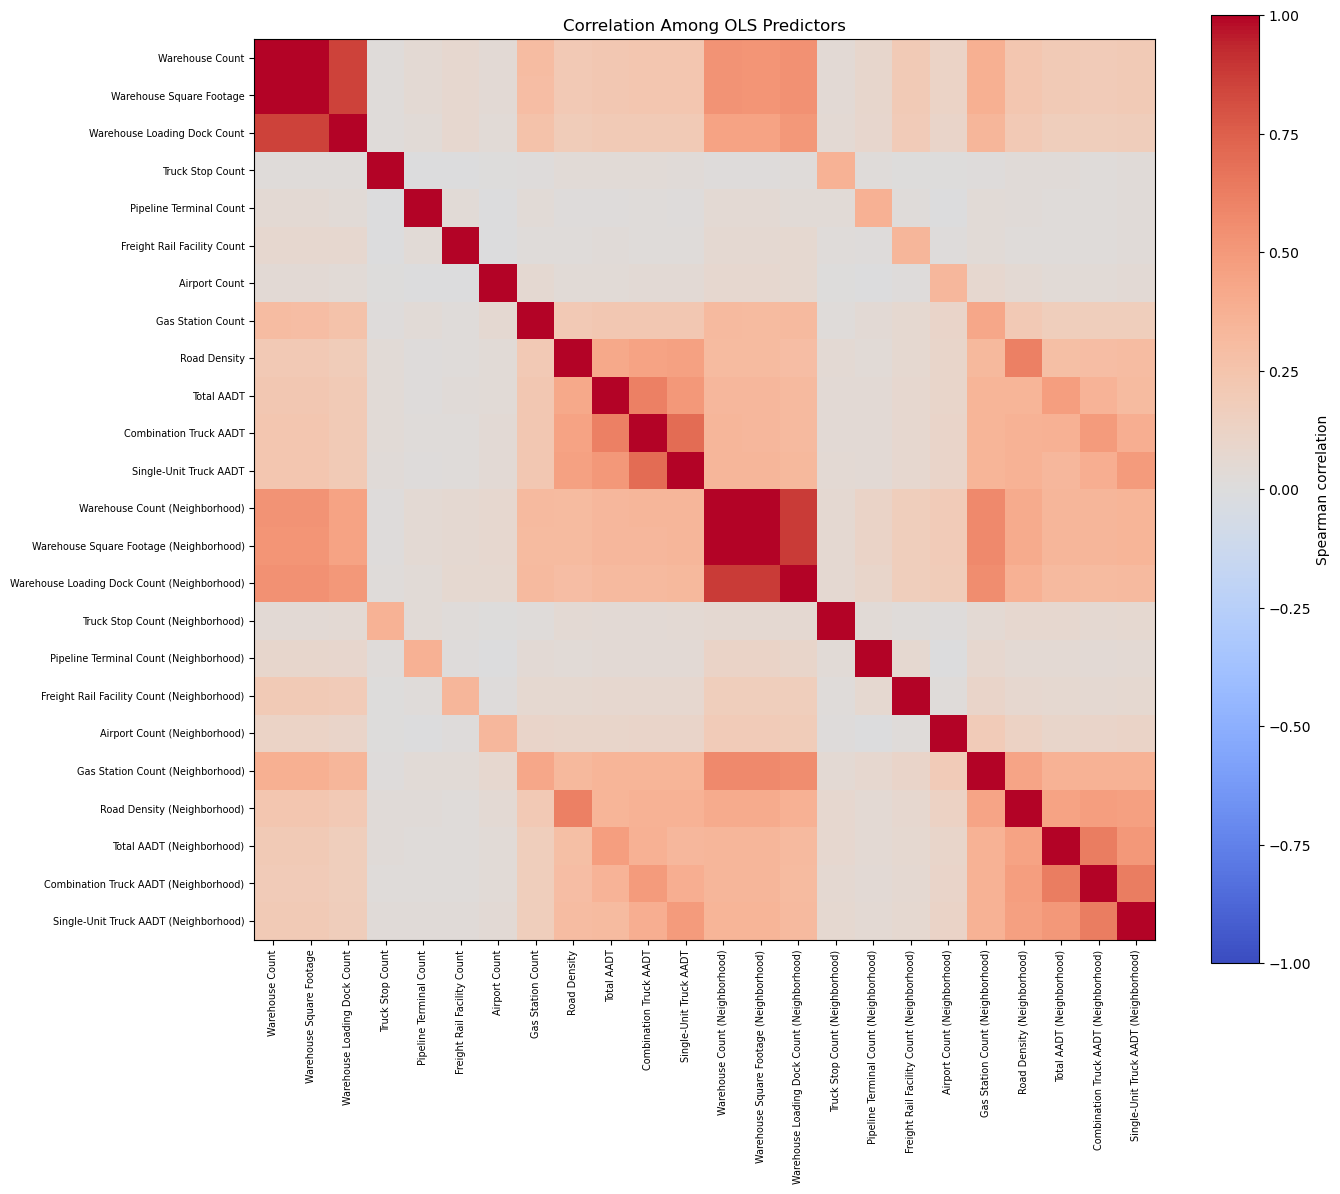

In [31]:
corr = df[feature_cols].corr(method="spearman")

plt.figure(figsize=(14, 12))
plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90, fontsize=7)
plt.yticks(range(len(feature_cols)), feature_cols, fontsize=7)
plt.title("Correlation Among OLS Predictors")
plt.tight_layout()
plt.show()

<h1> Multivariate Regression (OLS)

In [37]:
# Trying to estimate associations between idling and the freight-related characteristics in each grid cell.
# Predictors are standardized so the coefficients can be compared more directly across variables
# Moran's I then tells us whether there is still spatial structure left in the model residuals.

ols_results = []

for ycol in targets:
    X = (df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std()
    X = sm.add_constant(X)
    y = np.log1p(df[ycol])

    model = sm.OLS(y, X).fit(cov_type="HC3")
    ci = model.conf_int()

    res = pd.DataFrame({"feature": model.params.index, "coef": model.params.values, "ci_low": ci[0].values, "ci_high": ci[1].values, "p_value": model.pvalues.values})
    res["target"] = ycol
    ols_results.append(res[res["feature"] != "const"])

results_df = pd.concat(ols_results, ignore_index=True)
results_df

,feature,coef,ci_low,ci_high,p_value,target
0,Warehouse Count,0.043432,0.018803,0.068060,5.475098e-04,MDT_avg_da
1,Warehouse Square Footage,0.045005,0.013919,0.076092,4.546334e-03,MDT_avg_da
2,Warehouse Loading Dock Count,-0.011979,-0.037505,0.013547,3.576708e-01,MDT_avg_da
3,Truck Stop Count,0.032741,0.025475,0.040008,1.033061e-18,MDT_avg_da
4,Pipeline Terminal Count,0.005338,-0.004752,0.015427,2.997995e-01,MDT_avg_da
5,Freight Rail Facility Count,0.012712,0.003283,0.022141,8.232677e-03,MDT_avg_da
6,Airport Count,0.016306,0.009766,0.022845,1.024671e-06,MDT_avg_da
7,Gas Station Count,0.053903,0.002936,0.104870,3.818476e-02,MDT_avg_da
8,Road Density,0.153071,0.142711,0.163432,2.273932e-184,MDT_avg_da
9,Total AADT,0.003225,-0.002551,0.009001,2.738119e-01,MDT_avg_da


In [38]:
# Queen neighbors share either an edge or corner (matches the neighborhood definition used previously)
w = Queen.from_dataframe(grid, use_index=True)
w.transform = "R"

for ycol in targets:
    X = (df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std()
    X = sm.add_constant(X)
    y = np.log1p(df[ycol])

    model = sm.OLS(y, X).fit(cov_type="HC3")
    residuals = model.resid

    moran = Moran(residuals, w)

    print(f"{ycol}: Moran's I = {moran.I:.3f}, p = {moran.p_sim:.4f}")

C:\Users\x12la\anaconda3\lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


MDT_avg_da: Moran's I = 0.312, p = 0.0010
HDT_avg_da: Moran's I = 0.184, p = 0.0010
Total_avg_: Moran's I = 0.297, p = 0.0010


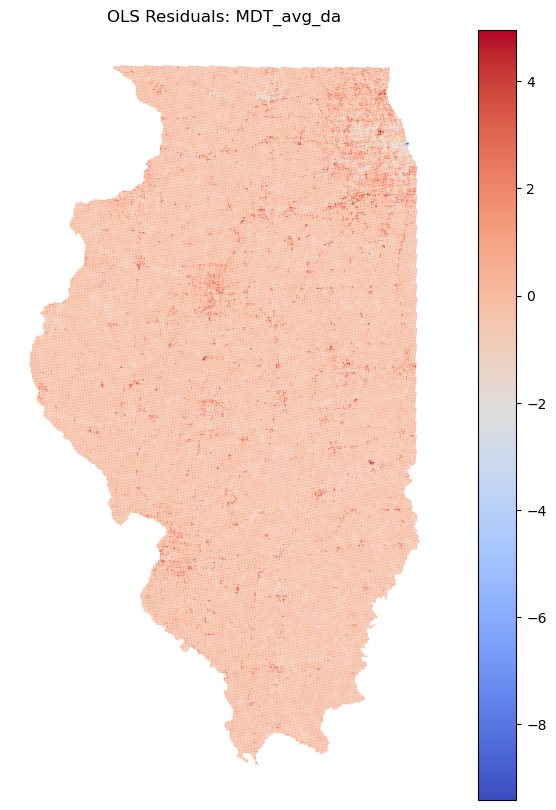

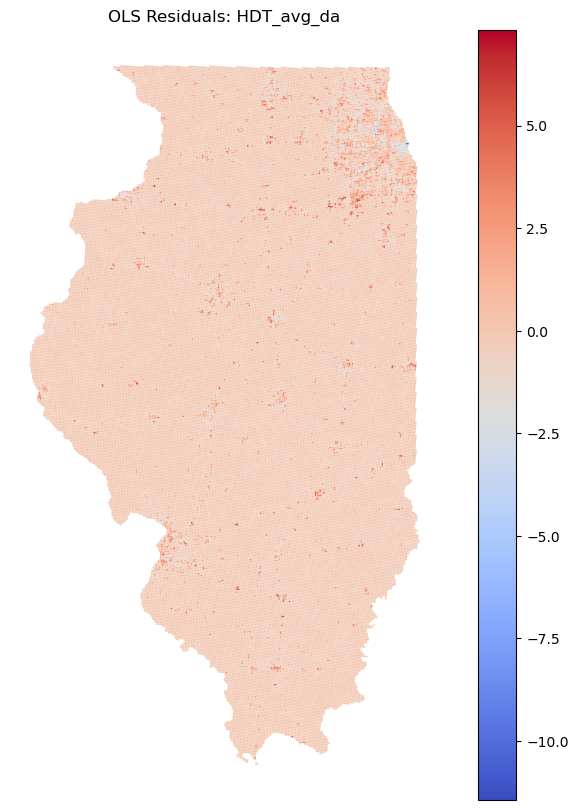

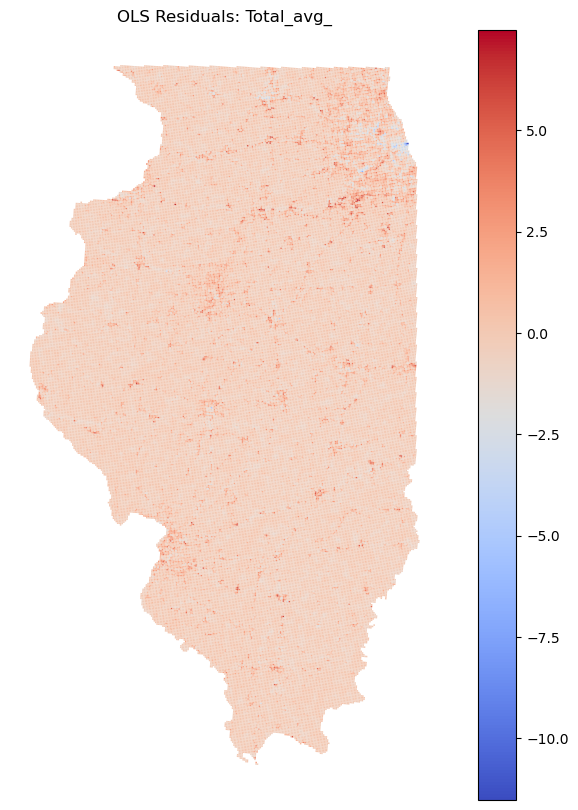

In [40]:
# Map OLS residuals to see where the model systematically over/underpredicts idling.
for ycol in targets:
    X = (df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std()
    X = sm.add_constant(X)
    y = np.log1p(df[ycol])

    model = sm.OLS(y, X).fit(cov_type="HC3")
    grid[f"{ycol}_residual"] = model.resid

    fig, ax = plt.subplots(figsize=(10, 10))
    grid.plot(column=f"{ycol}_residual", cmap="coolwarm", legend=True, ax=ax)
    ax.set_title(f"OLS Residuals: {ycol}")
    ax.set_axis_off()
    plt.show()

<h1> Light Gradident Boost Model 

In [49]:
# Doc sources used
# https://lightgbm.readthedocs.io/en/latest/
# https://lightgbm.readthedocs.io/en/v4.5.0/Parameters-Tuning.html 
# https://lightgbm.readthedocs.io/en/latest/_modules/lightgbm/callback.html
# https://scikit-learn.org/stable/modules/cross_validation.html?highlight=cross_validate
# https://scikit-learn.org/stable/common_pitfalls.html?highlight=linearregression  -> data leakage reading
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html?highlight=model_selection+train_test_split -> test/training spatial-cV
# https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html -> interpreting SHAP plots 
# https://shap.readthedocs.io/en/stable/generated/shap.plots.beeswarm.html
# https://scikit-learn.org/stable/modules/learning_curve.html -> Overfitting disc

C:\Users\x12la\anaconda3\lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)



MDT_avg_da
Candidate 0: RMSE = 0.456, trees = 305
Candidate 1: RMSE = 0.457, trees = 211
Candidate 2: RMSE = 0.457, trees = 231
Candidate 3: RMSE = 0.457, trees = 175
Selected candidate 0
Test RMSE = 0.446
Test R² = 0.721


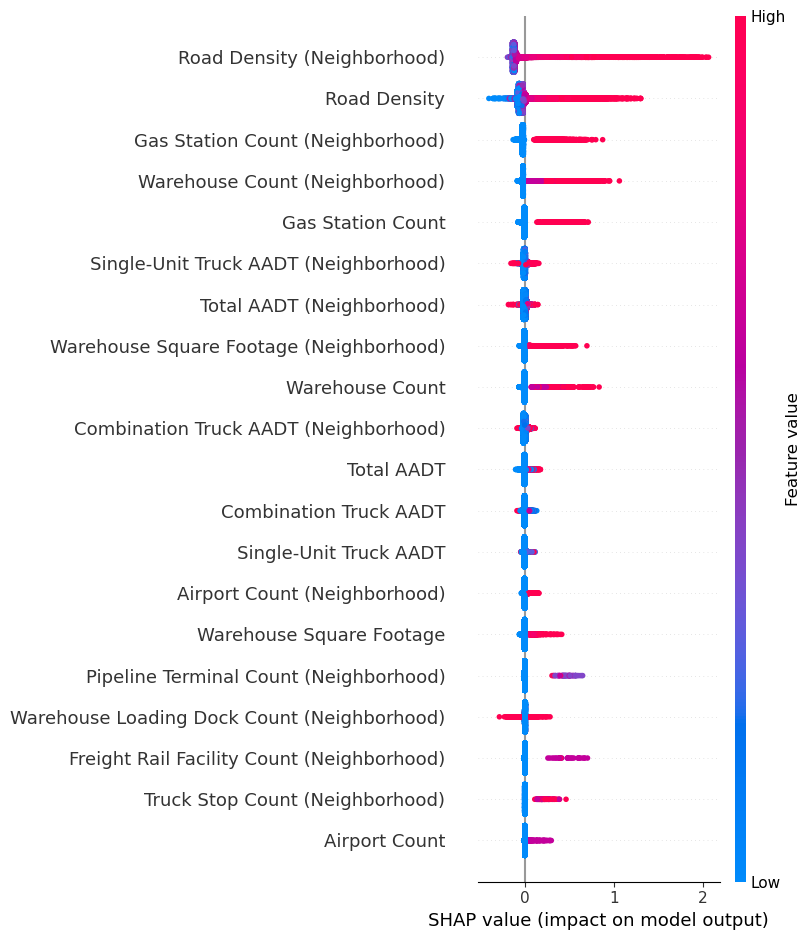

Moran's I = 0.174, p = 0.0010

HDT_avg_da
Candidate 0: RMSE = 0.528, trees = 165
Candidate 1: RMSE = 0.529, trees = 164
Candidate 2: RMSE = 0.530, trees = 233
Candidate 3: RMSE = 0.531, trees = 157
Selected candidate 0
Test RMSE = 0.511
Test R² = 0.608


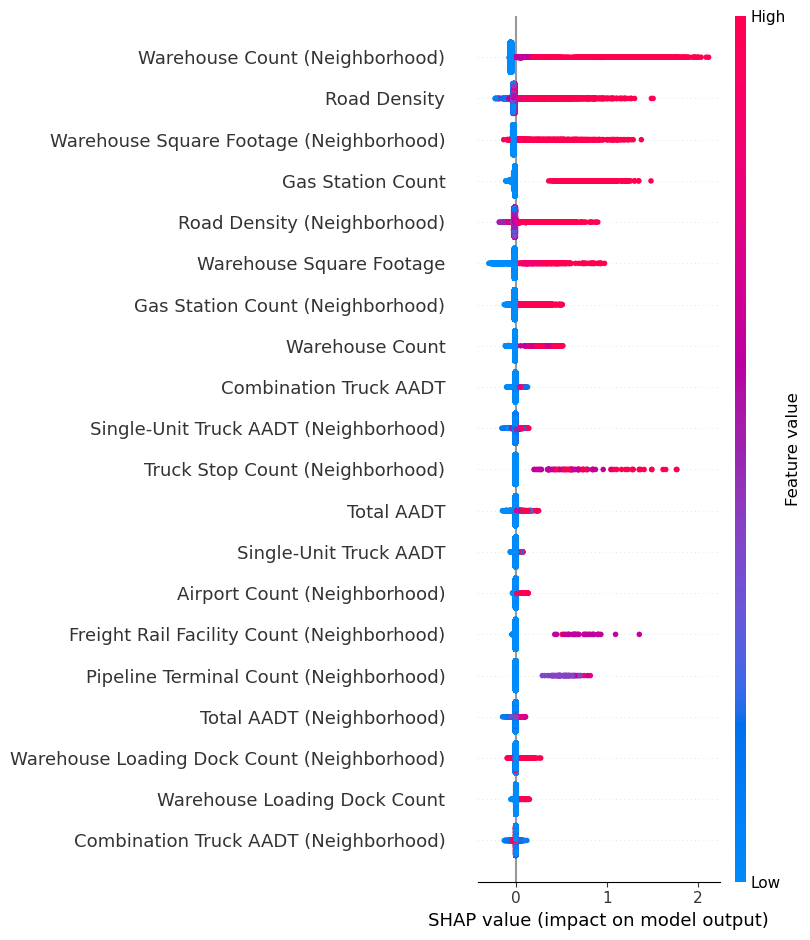

Moran's I = 0.080, p = 0.0010

Total_avg_
Candidate 0: RMSE = 0.572, trees = 236
Candidate 1: RMSE = 0.571, trees = 221
Candidate 2: RMSE = 0.573, trees = 248
Candidate 3: RMSE = 0.573, trees = 201
Selected candidate 1
Test RMSE = 0.557
Test R² = 0.707


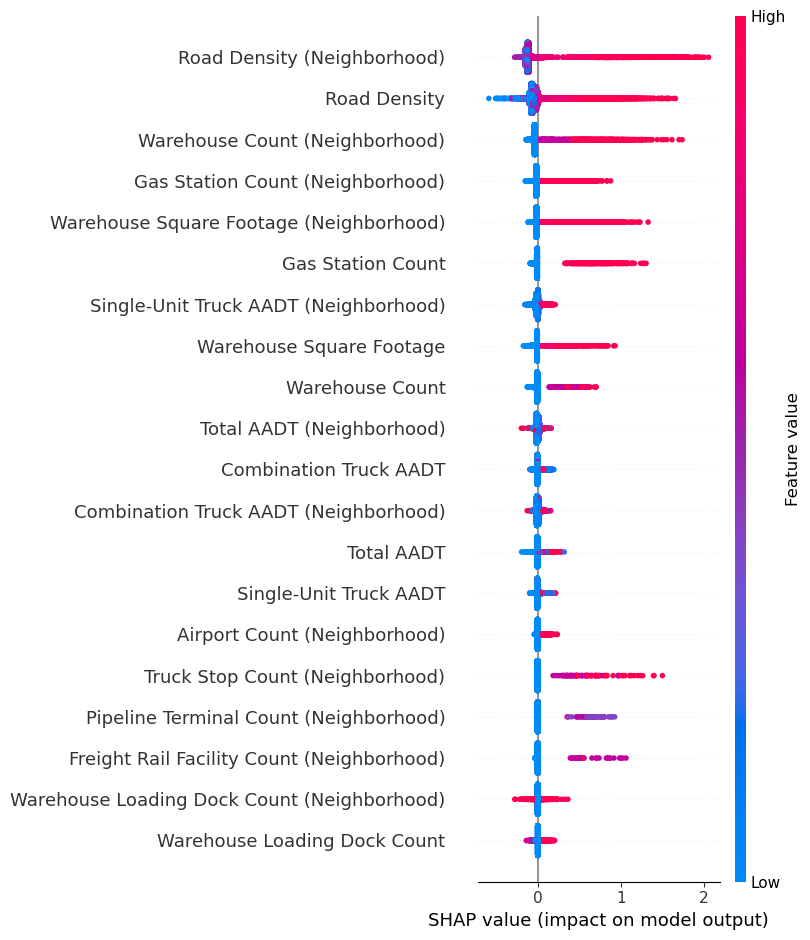

Moran's I = 0.143, p = 0.0010


In [50]:
# LightGBM to see whether nonlinear relationships better capture idling patterns.
# A few model structures are tested, while early stopping keeps them from adding unnecessary trees.
# Chat GPT helped with rewriting my original coding structure -> results did not change substantially from orig
lgbm_results = []

param_candidates = [
    {"num_leaves": 31, "min_child_samples": 50, "reg_lambda": 1},
    {"num_leaves": 63, "min_child_samples": 50, "reg_lambda": 1},
    {"num_leaves": 31, "min_child_samples": 100, "reg_lambda": 2},
    {"num_leaves": 63, "min_child_samples": 100, "reg_lambda": 2},
]

w = Queen.from_dataframe(grid, use_index=True)
w.transform = "R"

for ycol in targets:
    print(f"\n{ycol}")

    X = np.log1p(df[feature_cols])
    y = np.log1p(df[ycol])

    # Hold out 20% for the final performance check.
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Use part of the training data to select the model.
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

    candidate_results = []

    for i, params in enumerate(param_candidates):
        model = lgb.LGBMRegressor(n_estimators=5000, learning_rate=0.03, colsample_bytree=0.8, random_state=42, verbosity=-1, **params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(100, verbose=False)])

        val_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))
        candidate_results.append([i, val_rmse, model.best_iteration_])

        print(f"Candidate {i}: RMSE = {val_rmse:.3f}, trees = {model.best_iteration_}")

    # Keep the model with the lowest validation RMSE.
    best_i, best_val_rmse, best_iter = min(candidate_results, key=lambda x: x[1])
    best_params = param_candidates[best_i]

    # Fit that model to all training data and test it on data it has never seen.
    best_model = lgb.LGBMRegressor(n_estimators=best_iter, learning_rate=0.03, colsample_bytree=0.8, random_state=42, verbosity=-1, **best_params)
    best_model.fit(X_train_full, y_train_full)

    test_pred = best_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    r2 = r2_score(y_test, test_pred)

    print(f"Selected candidate {best_i}")
    print(f"Test RMSE = {rmse:.3f}")
    print(f"Test R² = {r2:.3f}")

    # SHAP shows what features are driving the nonlinear predictions.
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test)

    # Refit across the complete grid to see whether spatial structure is still left in the residuals.
    full_model = lgb.LGBMRegressor(n_estimators=best_iter, learning_rate=0.03, colsample_bytree=0.8, random_state=42, verbosity=-1, **best_params)
    full_model.fit(X, y)

    residuals = y - full_model.predict(X)
    moran = Moran(residuals, w)

    print(f"Moran's I = {moran.I:.3f}, p = {moran.p_sim:.4f}")
    
lgbm_df = pd.DataFrame(lgbm_results, columns=["target", "candidate", "trees", "test_rmse", "test_r2", "morans_i", "moran_p"])

<h4> Previous model did cross validation by using the hold out split, but the neighborhood grid cells may have been included in those test/training splits. so, here is a sensitivity where the data is broken up into spatial blocks first, then cross valdiation is done across sptial blocks

In [44]:
# Spatial cross-validation sensitivity test.
# Divide the region into large geographic blocks, then hold out one block at a time.
# This is a harder test than randomly holding out individual grid cells because neighboring cells stay together.

# Specifically, this post was v useful to discuss spatial CV
# https://stackoverflow.com/questions/58078127/k-folding-using-sklearn-with-specific-clusters-instead-of-spliting-with-specific
# https://stackoverflow.com/questions/40369987/sklearn-cross-validation-for-grouped-data

grid_cv = grid.to_crs("EPSG:26916").copy()
centers = grid_cv.geometry.centroid

grid_cv["x"] = centers.x
grid_cv["y"] = centers.y

# Split the domain into 4 sections east-west and 4 sections north-south.
grid_cv["x_block"] = pd.qcut(grid_cv["x"], 4, labels=False, duplicates="drop")
grid_cv["y_block"] = pd.qcut(grid_cv["y"], 4, labels=False, duplicates="drop")
grid_cv["spatial_block"] = grid_cv["y_block"] * 4 + grid_cv["x_block"]

print(grid_cv["spatial_block"].value_counts().sort_index())

0     2318
1     6319
2     6895
3     4531
4     6762
5     4266
6     4114
7     4920
8     7208
9     4053
10    3907
11    4894
12    3775
13    5424
14    5146
15    5718
Name: spatial_block, dtype: int64


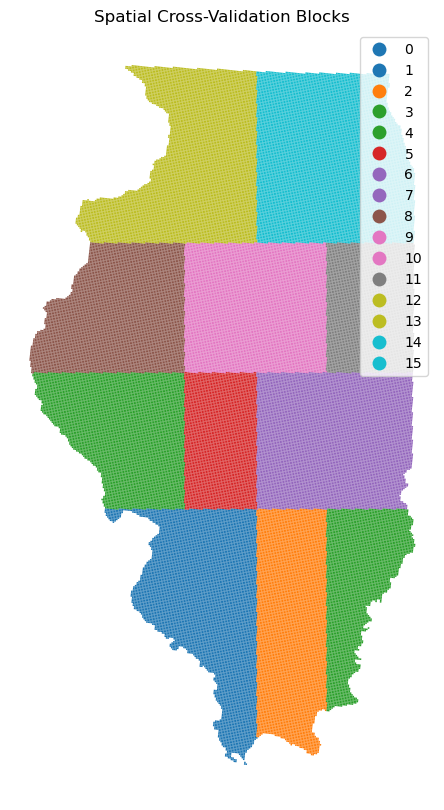

In [45]:
# Make sure the spatial folds look reasonable before using them.
fig, ax = plt.subplots(figsize=(10, 10))
grid_cv.plot(column="spatial_block", categorical=True, legend=True, ax=ax)
ax.set_title("Spatial Cross-Validation Blocks")
ax.set_axis_off()
plt.show()

In [46]:
# Use spatial blocks instead of a random train/test split to see how well the model generalizes geographically.

spatial_cv_results = []

for ycol in targets:
    print(f"\n{ycol}")

    X = np.log1p(df[feature_cols])
    y = np.log1p(df[ycol])

    # Use a simple, reasonably conservative LightGBM setup for the sensitivity test.
    params = {"num_leaves": 31, "min_child_samples": 50, "reg_lambda": 1}

    for block in sorted(grid_cv["spatial_block"].dropna().unique()):
        test_idx = grid_cv.index[grid_cv["spatial_block"] == block]
        train_idx = grid_cv.index[grid_cv["spatial_block"] != block]

        X_train, X_test = X.loc[train_idx], X.loc[test_idx]
        y_train, y_test = y.loc[train_idx], y.loc[test_idx]

        model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, colsample_bytree=0.8, random_state=42, verbosity=-1, **params)
        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)

        spatial_cv_results.append([ycol, block, len(test_idx), rmse, r2])

        print(f"Block {int(block):2d}: n={len(test_idx):4d}, RMSE={rmse:.3f}, R²={r2:.3f}")


MDT_avg_da
Block  0: n=2318, RMSE=0.605, R²=0.697
Block  1: n=6319, RMSE=0.381, R²=0.496
Block  2: n=6895, RMSE=0.324, R²=0.530
Block  3: n=4531, RMSE=0.319, R²=0.399
Block  4: n=6762, RMSE=0.338, R²=0.540
Block  5: n=4266, RMSE=0.438, R²=0.579
Block  6: n=4114, RMSE=0.382, R²=0.648
Block  7: n=4920, RMSE=0.408, R²=0.520
Block  8: n=7208, RMSE=0.316, R²=0.511
Block  9: n=4053, RMSE=0.546, R²=0.600
Block 10: n=3907, RMSE=0.403, R²=0.605
Block 11: n=4894, RMSE=0.421, R²=0.571
Block 12: n=3775, RMSE=0.419, R²=0.554
Block 13: n=5424, RMSE=0.379, R²=0.476
Block 14: n=5146, RMSE=0.525, R²=0.566
Block 15: n=5718, RMSE=0.915, R²=0.655

HDT_avg_da
Block  0: n=2318, RMSE=0.740, R²=0.499
Block  1: n=6319, RMSE=0.407, R²=0.327
Block  2: n=6895, RMSE=0.410, R²=0.380
Block  3: n=4531, RMSE=0.306, R²=0.264
Block  4: n=6762, RMSE=0.304, R²=0.418
Block  5: n=4266, RMSE=0.389, R²=0.488
Block  6: n=4114, RMSE=0.392, R²=0.596
Block  7: n=4920, RMSE=0.378, R²=0.376
Block  8: n=7208, RMSE=0.255, R²=0.389
B

In [47]:
spatial_cv_df = pd.DataFrame(spatial_cv_results, columns=["target", "block", "n_test", "rmse", "r2"])
spatial_cv_df

,target,block,n_test,rmse,r2
0,MDT_avg_da,0,2318,0.605294,0.696886
1,MDT_avg_da,1,6319,0.380921,0.495577
2,MDT_avg_da,2,6895,0.324124,0.530428
3,MDT_avg_da,3,4531,0.319235,0.399182
4,MDT_avg_da,4,6762,0.338336,0.540408
5,MDT_avg_da,5,4266,0.437996,0.579495
6,MDT_avg_da,6,4114,0.382190,0.647961
7,MDT_avg_da,7,4920,0.407627,0.519585
8,MDT_avg_da,8,7208,0.316366,0.510661
9,MDT_avg_da,9,4053,0.545925,0.600240


In [48]:
# Summarize how performance changes when entire parts of the domain are held out.
spatial_cv_df.groupby("target").agg(mean_r2=("r2", "mean"), min_r2=("r2", "min"), max_r2=("r2", "max"), mean_rmse=("rmse", "mean"))

,mean_r2,min_r2,max_r2,mean_rmse
target,,,,
HDT_avg_da,0.434143,0.263626,0.596006,0.476309
MDT_avg_da,0.559231,0.399182,0.696886,0.444962
Total_avg_,0.555103,0.379841,0.687586,0.542648


<h1> Save to a CSV file

In [51]:
target_names = {"MDT_avg_da": "MDT", "HDT_avg_da": "HDT", "Total_avg_": "Total"}

with pd.ExcelWriter("Idling_Statistical_Results.xlsx") as writer:
    for target, name in target_names.items():
        spearman_df[spearman_df["target"] == target].to_excel(writer, sheet_name=f"Spearman_{name}", index=False)
        results_df[results_df["target"] == target].to_excel(writer, sheet_name=f"OLS_{name}", index=False)
        lgbm_df[lgbm_df["target"] == target].to_excel(writer, sheet_name=f"LightGBM_{name}", index=False)